# Когортный анализ retention и LTV

### Задача
Оценить удержание пользователей и динамику LTV в разрезе когорт и каналов привлечения для оптимизации маркетингового бюджета.

*Примечание: в связи с NDA исходные данные обезличены и заменены на синтетические, сохраняющие структуру и паттерны реальных данных.*

---

#### Методология
- **Когортный анализ** — группировка пользователей по месяцу регистрации
- **Retention** — процент пользователей, совершивших покупку в каждом месяце после регистрации
- **LTV (Lifetime Value)** — кумулятивная выручка на пользователя

---

### Ключевые выводы

#### Retention
- Retention на 3-й месяц: **48–54%** в зависимости от когорты
- Retention на 6-й месяц: **13–18%**
- Наиболее стабильное удержание у когорт начала 2023 года (январь–март)

#### LTV по каналам (12-month)
- **Referral** — $4,442 (лидер по LTV)
- **Google Ads** — $4,177
- **FB Ads** — $4,089
- **Organic** — $3,825

---

#### Рекомендации
1. **Увеличить бюджет на referral-программу** — показывает максимальный LTV при минимальных затратах на привлечение
2. **Пересмотреть стратегию по organic-трафику** — LTV на 14% ниже лидера, требуется анализ качества трафика
3. **Google Ads vs FB Ads** — при схожем LTV оценить CAC: если CAC на FB Ads выше, перераспределить бюджет в пользу Google

---

#### Артефакты
- `retention_heatmap.png` — тепловая карта удержания по когортам
- `ltv_by_cohort.png` — динамика кумулятивного LTV
- `ltv_by_channel.png` — сравнение LTV по каналам привлечения
- `cohort_analysis.ipynb` — Jupyter Notebook с кодом и расчётами

---

#### Инструменты
- Python (pandas, numpy, matplotlib, seaborn)
- Jupyter Notebook

## Шаг 1. Генерация данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Сетка для воспроизводимости
np.random.seed(42)

# Параметры
n_users = 10000
start_date = '2023-01-01'
end_date = '2024-03-31'

# Генерируем даты регистрации
reg_dates = pd.date_range(start_date, end_date, freq='D')
reg_dates_list = np.random.choice(reg_dates, n_users)

# Генерируем данные пользователей
users = pd.DataFrame({
    'user_id': range(n_users),
    'reg_date': reg_dates_list,
    'first_source': np.random.choice(['organic', 'fb_ads', 'google_ads', 'referral'], n_users, p=[0.4, 0.3, 0.2, 0.1])
})

# Добавляем сумму первого заказа (для LTV)
users['first_order_value'] = np.random.gamma(2, 500, n_users).round(0)
users['first_order_value'] = users['first_order_value'].clip(100, 5000)

# Генерируем активности (транзакции)
transactions = []
for _, user in users.iterrows():
    user_id = user['user_id']
    reg_date = user['reg_date']
    first_value = user['first_order_value']

    # Количество месяцев активности (от 1 до 8)
    months_active = np.random.poisson(3) + 1
    months_active = min(months_active, 8)

    # Первый заказ в месяц регистрации
    transactions.append({
        'user_id': user_id,
        'transaction_date': reg_date + pd.Timedelta(days=np.random.randint(0, 14)),
        'revenue': first_value,
        'month_number': 0
    })

    # Последующие заказы
    for m in range(1, months_active):
        # Не каждый месяц активен, с вероятностью 70%
        if np.random.random() < 0.7:
            transaction_date = reg_date + pd.DateOffset(months=m) + pd.Timedelta(days=np.random.randint(-7, 15))
            if transaction_date <= pd.to_datetime(end_date):
                # Сумма заказа уменьшается со временем или растет — добавим вариативности
                revenue = first_value * np.random.uniform(0.6, 1.3)
                transactions.append({
                    'user_id': user_id,
                    'transaction_date': transaction_date,
                    'revenue': revenue,
                    'month_number': m
                })

df_transactions = pd.DataFrame(transactions)

# Добавляем информацию о когорте
df_transactions['cohort'] = df_transactions['user_id'].map(users.set_index('user_id')['reg_date']).dt.to_period('M')
df_transactions['transaction_month'] = df_transactions['transaction_date'].dt.to_period('M')
df_transactions['tenure'] = (df_transactions['transaction_month'] - df_transactions['cohort']).apply(lambda x: x.n)

# Убираем дубликаты если есть
df_transactions = df_transactions.drop_duplicates(subset=['user_id', 'tenure'])

## Шаг 2. Retention matrix (процент вернувшихся)


Retention Matrix (%):
tenure       0     1     2     3     4     5     6    7    8
cohort                                                      
2023-01  100.0  77.7  66.2  48.0  30.2  15.9   7.9  2.3  0.0
2023-02  100.0  91.6  68.6  54.5  31.0  15.4   5.2  2.8  0.9
2023-03  100.0  91.1  71.8  48.7  32.0  16.4   6.1  4.3  0.8
2023-04  100.0  87.7  68.7  52.8  33.6  17.2   8.9  3.8  0.6
2023-05  100.0  89.1  67.5  51.5  32.3  18.0   8.6  3.0  0.6
2023-06  100.0  92.9  69.1  48.8  34.9  17.5   8.6  2.9  0.2
2023-07  100.0  86.0  61.6  49.3  32.8  17.1   7.6  2.9  0.4
2023-08  100.0  80.0  64.6  45.1  26.6  13.5   7.7  2.5  0.0
2023-09  100.0  92.9  71.7  51.4  30.4  16.2  10.0  0.0  0.0
2023-10  100.0  89.7  69.2  50.1  30.8  17.5   0.0  0.0  0.0


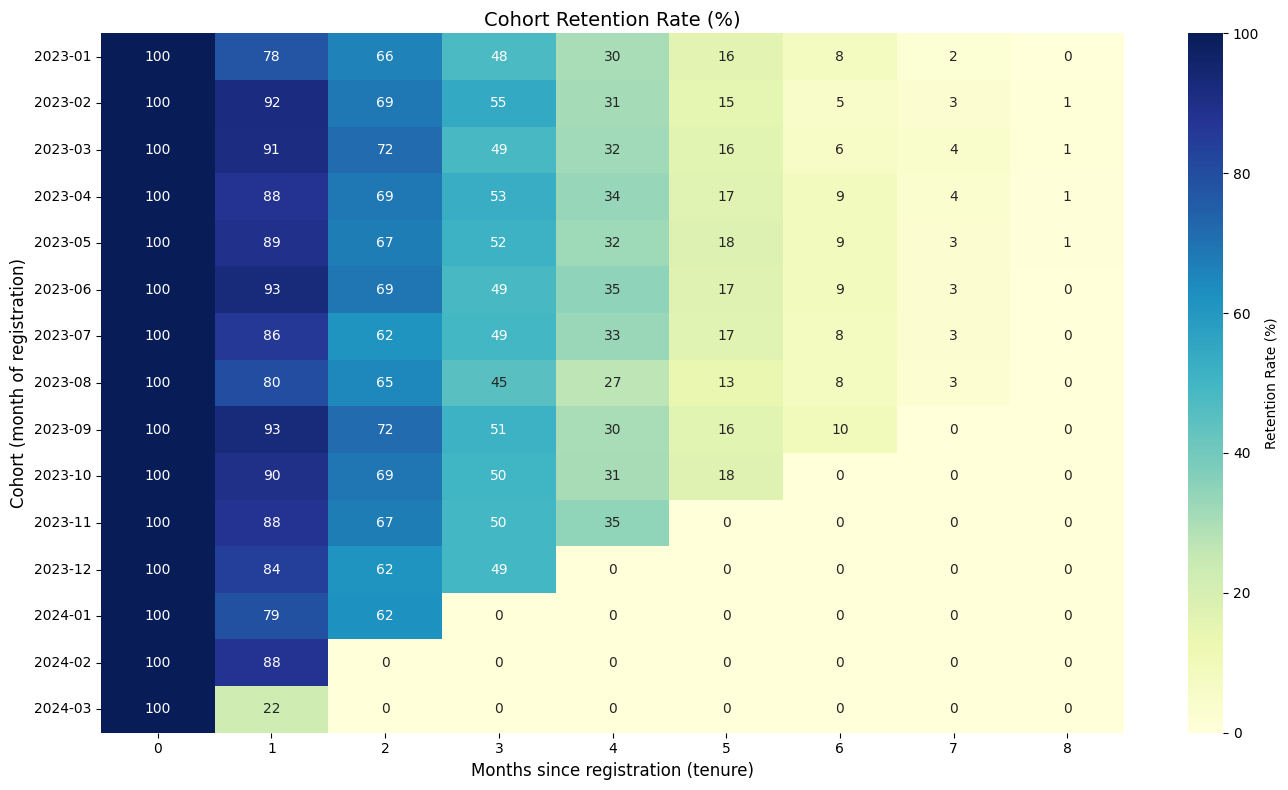

In [2]:
# Получаем уникальных пользователей по когортам и tenure
retention_data = df_transactions.groupby(['cohort', 'tenure'])['user_id'].nunique().reset_index()

# Получаем размер когорты (tenure = 0)
cohort_sizes = retention_data[retention_data['tenure'] == 0][['cohort', 'user_id']]
cohort_sizes.columns = ['cohort', 'cohort_size']

# Считаем retention rate
retention = retention_data.merge(cohort_sizes, on='cohort')
retention['retention_rate'] = (retention['user_id'] / retention['cohort_size']) * 100

# Сводная таблица для тепловой карты
retention_pivot = retention.pivot(index='cohort', columns='tenure', values='retention_rate').fillna(0)

# Выводим
print("Retention Matrix (%):")
print(retention_pivot.round(1).head(10))

# Тепловая карта
plt.figure(figsize=(14, 8))
sns.heatmap(retention_pivot, annot=True, fmt='.0f', cmap='YlGnBu',
            cbar_kws={'label': 'Retention Rate (%)'})
plt.title('Cohort Retention Rate (%)', fontsize=14)
plt.xlabel('Months since registration (tenure)', fontsize=12)
plt.ylabel('Cohort (month of registration)', fontsize=12)
plt.tight_layout()
plt.savefig('retention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Шаг 3. Когортный LTV (кумулятивная выручка на пользователя)


Cumulative LTV by Cohort ($ per user):
tenure        0       1       2       3       4       5       6       7  \
cohort                                                                    
2023-01   985.0  1736.0  2388.0  2881.0  3170.0  3341.0  3415.0  3444.0   
2023-02  1030.0  1960.0  2633.0  3168.0  3489.0  3647.0  3699.0  3734.0   
2023-03   979.0  1806.0  2461.0  2924.0  3220.0  3376.0  3443.0  3489.0   
2023-04  1037.0  1903.0  2577.0  3080.0  3384.0  3547.0  3622.0  3650.0   
2023-05  1024.0  1900.0  2581.0  3081.0  3390.0  3578.0  3658.0  3682.0   
2023-06  1007.0  1859.0  2514.0  2956.0  3294.0  3463.0  3536.0  3558.0   
2023-07  1004.0  1780.0  2379.0  2830.0  3139.0  3284.0  3341.0  3368.0   
2023-08  1046.0  1858.0  2522.0  2964.0  3219.0  3347.0  3432.0  3464.0   
2023-09   981.0  1879.0  2538.0  2985.0  3263.0  3432.0  3523.0     0.0   
2023-10  1009.0  1851.0  2529.0  3012.0  3313.0  3481.0     0.0     0.0   

tenure        8  
cohort           
2023-01     0.0  
2023-

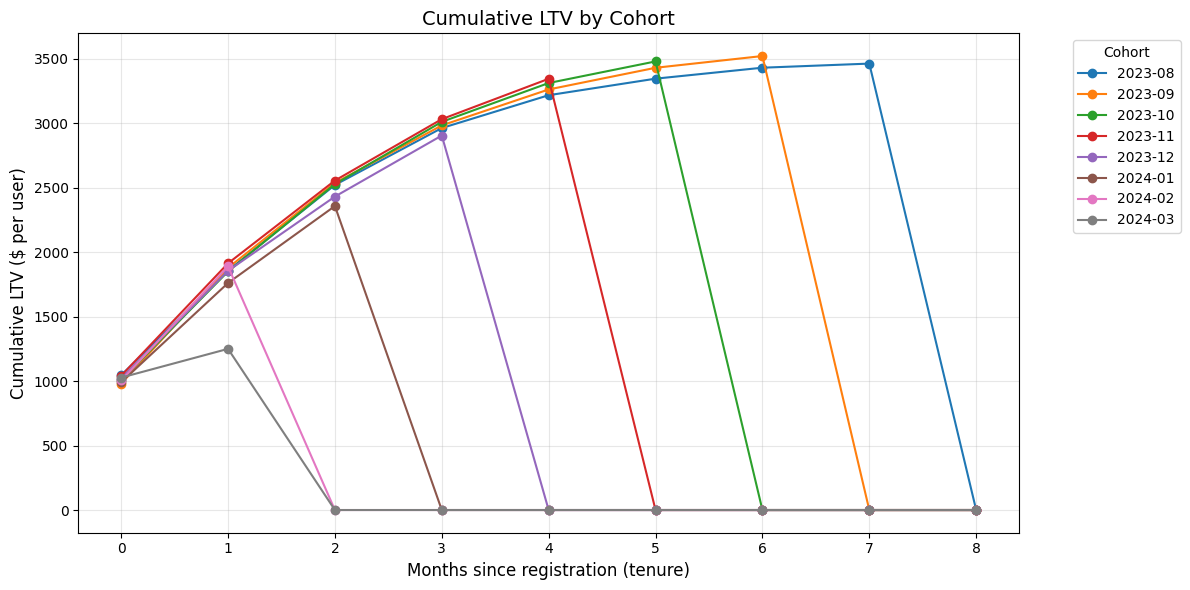

In [3]:
# Считаем выручку по когортам и tenure
revenue_by_cohort = df_transactions.groupby(['cohort', 'tenure'])['revenue'].sum().reset_index()

# Добавляем размер когорты
revenue_by_cohort = revenue_by_cohort.merge(cohort_sizes, on='cohort')

# Считаем LTV на пользователя
revenue_by_cohort['ltv_per_user'] = revenue_by_cohort['revenue'] / revenue_by_cohort['cohort_size']

# Кумулятивный LTV
revenue_by_cohort['cumulative_ltv'] = revenue_by_cohort.groupby('cohort')['ltv_per_user'].cumsum()

# Сводная таблица LTV
ltv_pivot = revenue_by_cohort.pivot(index='cohort', columns='tenure', values='cumulative_ltv').fillna(0)

print("\nCumulative LTV by Cohort ($ per user):")
print(ltv_pivot.round(0).head(10))

# График LTV по когортам
plt.figure(figsize=(12, 6))
for cohort in ltv_pivot.index[-8:]:  # последние 8 когорт
    plt.plot(ltv_pivot.columns, ltv_pivot.loc[cohort], marker='o', label=str(cohort))

plt.title('Cumulative LTV by Cohort', fontsize=14)
plt.xlabel('Months since registration (tenure)', fontsize=12)
plt.ylabel('Cumulative LTV ($ per user)', fontsize=12)
plt.legend(title='Cohort', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ltv_by_cohort.png', dpi=150, bbox_inches='tight')
plt.show()

## Шаг 4. Анализ по каналам привлечения (добавляем бизнес-ценность)


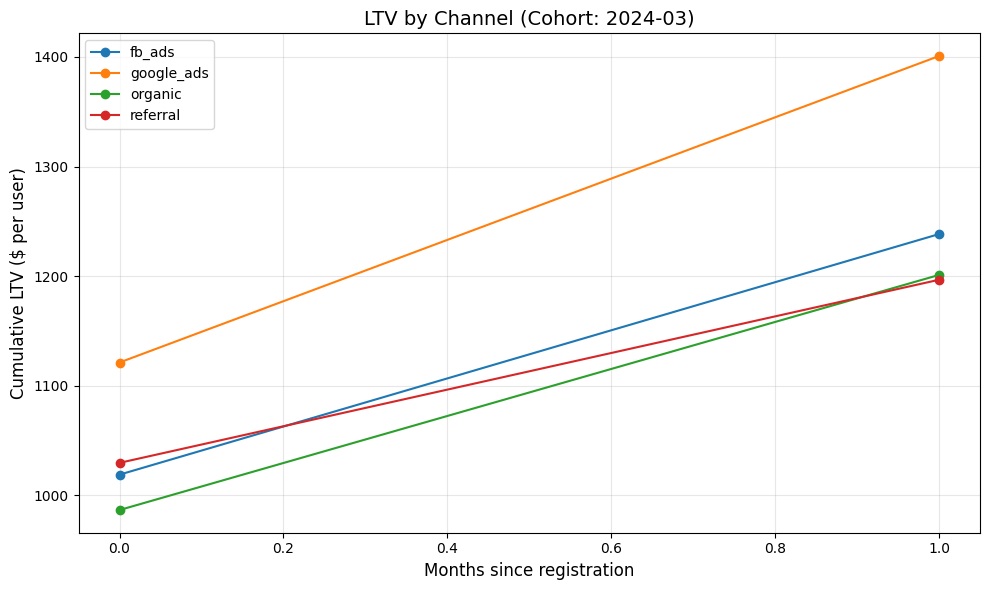


KEY INSIGHTS

GOOGLE_ADS:
  - 12-month LTV: $4,177

FB_ADS:
  - 12-month LTV: $4,089

ORGANIC:
  - 12-month LTV: $3,825

REFERRAL:
  - 12-month LTV: $4,442


In [4]:
# Добавляем канал привлечения к транзакциям
df_transactions['source'] = df_transactions['user_id'].map(users.set_index('user_id')['first_source'])

# Retention по каналам
retention_by_source = df_transactions.groupby(['source', 'cohort', 'tenure'])['user_id'].nunique().reset_index()
cohort_sizes_by_source = df_transactions[df_transactions['tenure'] == 0].groupby(['source', 'cohort'])['user_id'].nunique().reset_index()
cohort_sizes_by_source.columns = ['source', 'cohort', 'cohort_size']

retention_by_source = retention_by_source.merge(cohort_sizes_by_source, on=['source', 'cohort'])
retention_by_source['retention_rate'] = (retention_by_source['user_id'] / retention_by_source['cohort_size']) * 100

# LTV по каналам
revenue_by_source = df_transactions.groupby(['source', 'cohort', 'tenure'])['revenue'].sum().reset_index()
revenue_by_source = revenue_by_source.merge(cohort_sizes_by_source, on=['source', 'cohort'])
revenue_by_source['ltv_per_user'] = revenue_by_source['revenue'] / revenue_by_source['cohort_size']
revenue_by_source['cumulative_ltv'] = revenue_by_source.groupby(['source', 'cohort'])['ltv_per_user'].cumsum()

# Сравнительный график LTV по каналам (для последней когорты)
latest_cohort = revenue_by_source['cohort'].max()
latest_data = revenue_by_source[revenue_by_source['cohort'] == latest_cohort]

plt.figure(figsize=(10, 6))
for source in latest_data['source'].unique():
    data = latest_data[latest_data['source'] == source]
    plt.plot(data['tenure'], data['cumulative_ltv'], marker='o', label=source)

plt.title(f'LTV by Channel (Cohort: {latest_cohort})', fontsize=14)
plt.xlabel('Months since registration', fontsize=12)
plt.ylabel('Cumulative LTV ($ per user)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ltv_by_channel.png', dpi=150, bbox_inches='tight')
plt.show()

# Вывод ключевых метрик
print("\n" + "="*50)
print("KEY INSIGHTS")
print("="*50)

for source in users['first_source'].unique():
    source_ltv = revenue_by_source[revenue_by_source['source'] == source]
    source_ltv_12m = source_ltv[source_ltv['tenure'] == 12]['cumulative_ltv'].values if 12 in source_ltv['tenure'].values else source_ltv['cumulative_ltv'].max()
    print(f"\n{source.upper()}:")
    print(f"  - 12-month LTV: ${source_ltv_12m:,.0f}" if source_ltv_12m else "  - LTV data available")